Lab 03: Data Visualization Principles
Roll Number: 24i-2603  
Section:DS-B


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)


# Task 1: Same Data, Multiple Chart Types

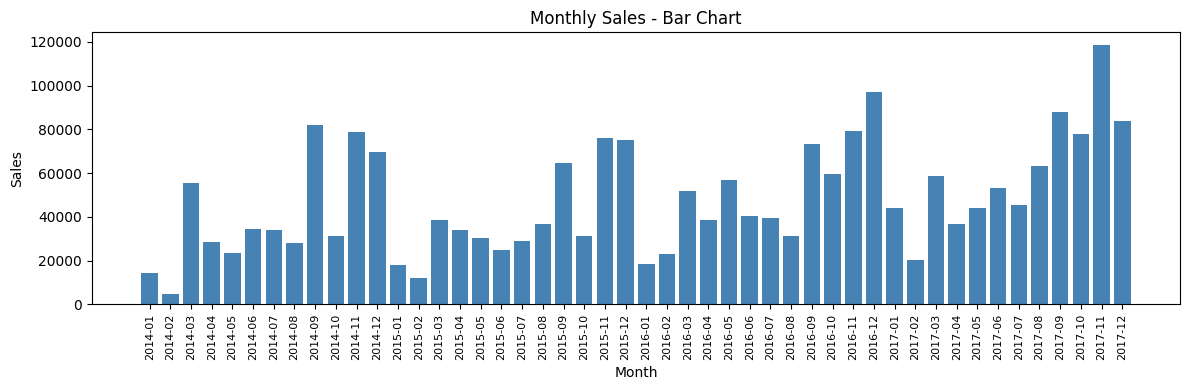

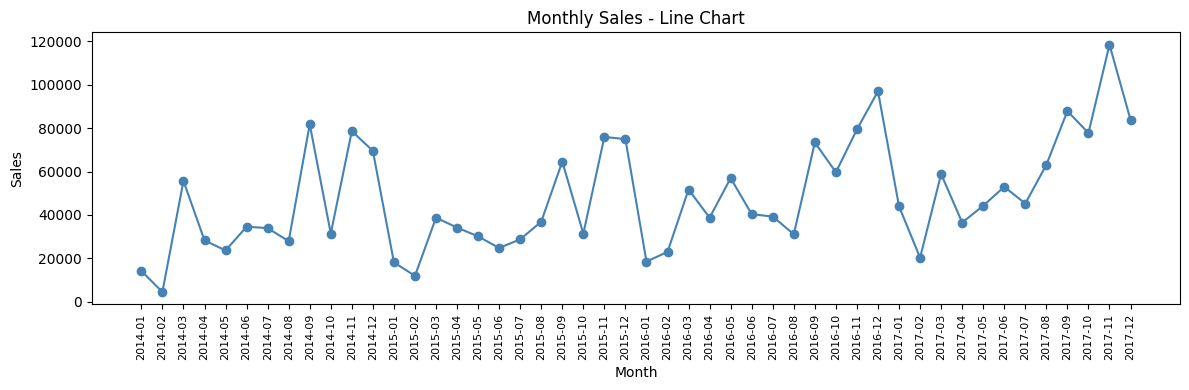

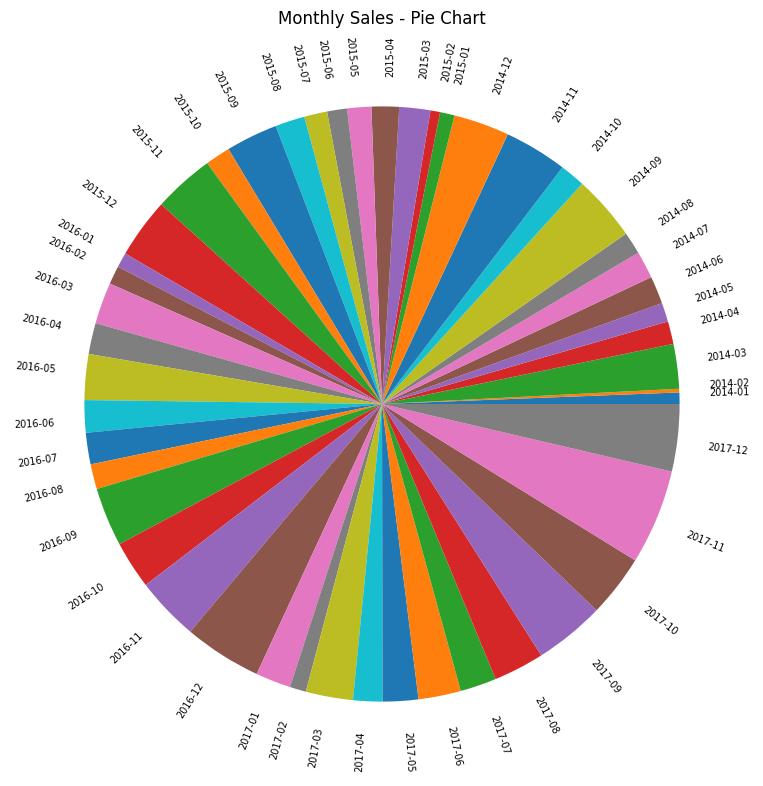

In [2]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

# 1. Bar Chart
plt.figure(figsize=(12, 4))
plt.bar(monthly_sales['YearMonth'], monthly_sales['Sales'], color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Sales - Bar Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# 2. Line Chart
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Sales - Line Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# 3. Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(monthly_sales['Sales'], labels=monthly_sales['YearMonth'], rotatelabels=True, textprops={'fontsize': 7})
plt.title('Monthly Sales - Pie Chart')
plt.tight_layout()
plt.show()

# Explanation:
# - Best for trend: Line chart connects monthly points in order, making it easy to see ups, downs, and seasonal patterns.
# - Hides trend: Pie chart has no chronological order and comparing slice angles is very difficult.


# Task 2: Effectiveness & Appropriateness

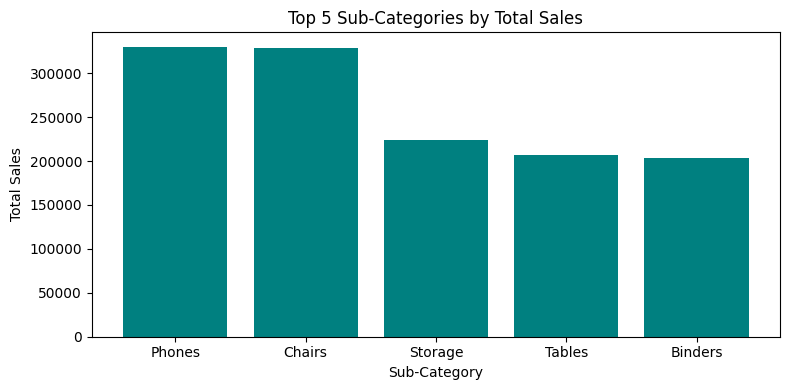

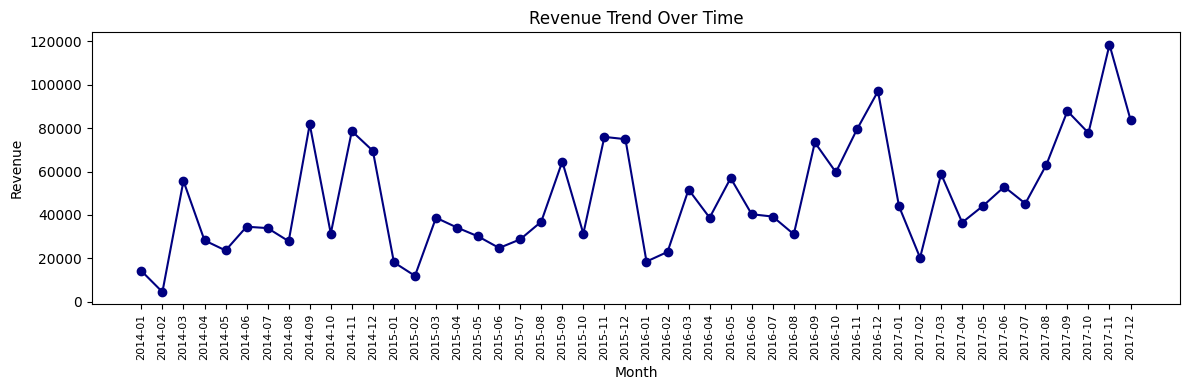

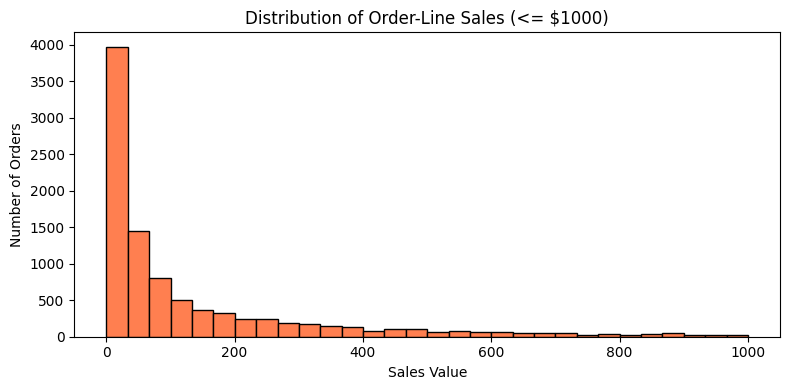

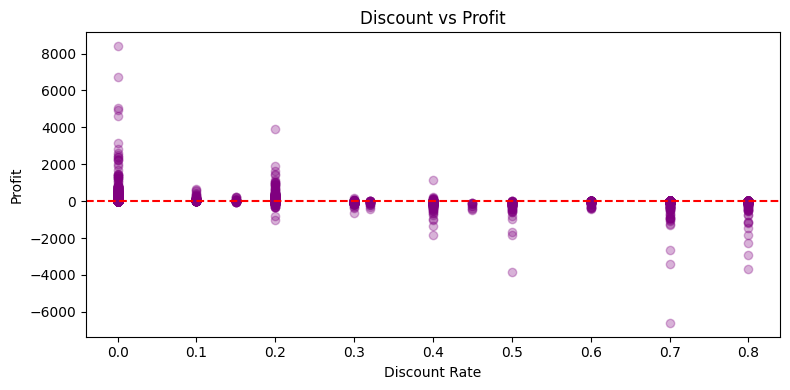

In [3]:
# 1. Compare total sales across the top 5 sub-categories
# Justification: Bar chart aligns categories on a common zero baseline for easy comparison. Pie/radar charts make judging small angle differences difficult.
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()
plt.figure(figsize=(8, 4))
plt.bar(top5_subcat['Sub-Category'], top5_subcat['Sales'], color='teal')
plt.title('Top 5 Sub-Categories by Total Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# 2. Show the revenue trend over time
# Justification: Line chart shows continuous progress across 48 months. A bar chart with 48 bars clutters the axis and breaks visual flow.
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='navy')
plt.xticks(rotation=90, fontsize=8)
plt.title('Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# 3. Show the distribution of order-line sales values
# Justification: Histogram groups orders into intervals, showing most orders are small and a few are large. An average bar hides the whole distribution.
plt.figure(figsize=(8, 4))
plt.hist(df['Sales'][df['Sales'] <= 1000], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Order-Line Sales (<= $1000)')
plt.xlabel('Sales Value')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# 4. Show the relationship between discount level and profit
# Justification: Scatter plot maps individual orders to show high discounts cause losses. A line chart falsely implies a sequence.
plt.figure(figsize=(8, 4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


# Task 3: Color Selection

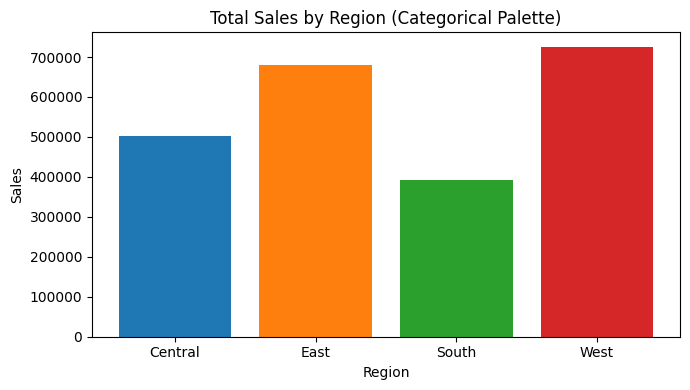

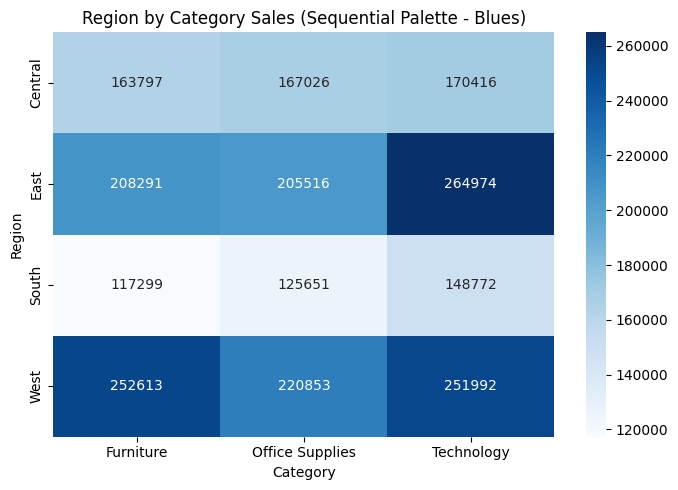

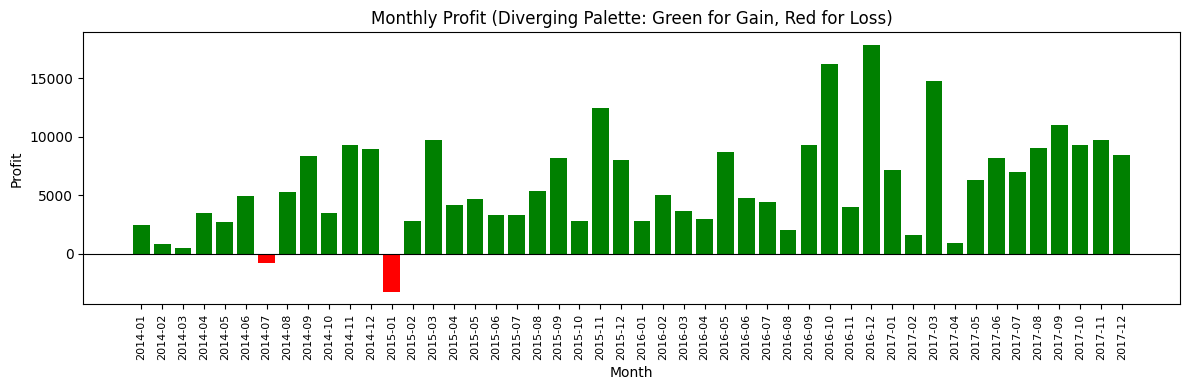

In [4]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_cat = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
monthly_profit = df.groupby('YearMonth')['Profit'].sum().reset_index()

# (a) Categorical palette: Regions are unordered groups, so each gets a distinct color without implied rank.
plt.figure(figsize=(7, 4))
colors_cat = sns.color_palette('tab10', len(region_sales))
plt.bar(region_sales['Region'], region_sales['Sales'], color=colors_cat)
plt.title('Total Sales by Region (Categorical Palette)')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# (b) Sequential palette: Heatmap uses light-to-dark blues to show increasing sales magnitude.
plt.figure(figsize=(7, 5))
sns.heatmap(region_cat, annot=True, fmt='.0f', cmap='Blues')
plt.title('Region by Category Sales (Sequential Palette - Blues)')
plt.tight_layout()
plt.show()

# (c) Diverging palette: Monthly profit crosses zero, so green represents gain and red represents loss.
plt.figure(figsize=(12, 4))
profit_colors = ['green' if p >= 0 else 'red' for p in monthly_profit['Profit']]
plt.bar(monthly_profit['YearMonth'], monthly_profit['Profit'], color=profit_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=8)
plt.title('Monthly Profit (Diverging Palette: Green for Gain, Red for Loss)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


# Task 4: Accessibility

WCAG AA Contrast Check (Threshold = 4.5:1):
Region color 1: Contrast = 4.82:1 -> PASS
Region color 2: Contrast = 2.53:1 -> FAIL
Region color 3: Contrast = 3.40:1 -> FAIL
Region color 4: Contrast = 5.02:1 -> PASS


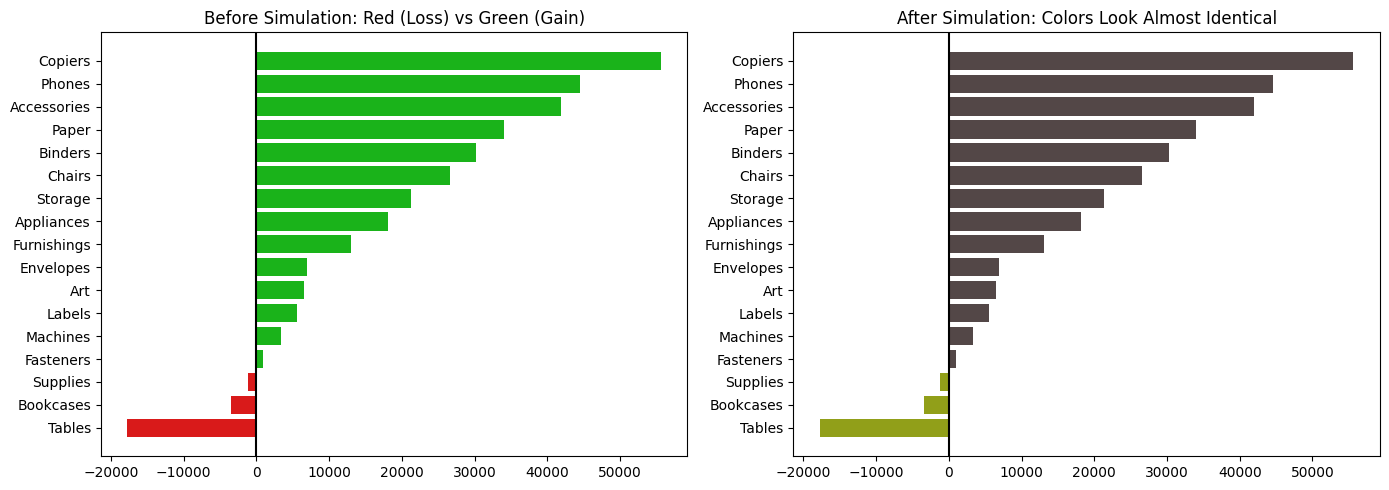

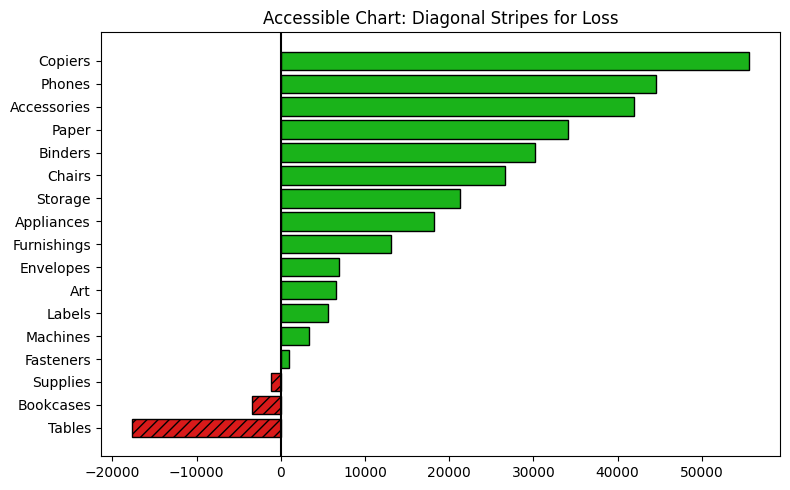

In [5]:
# (a) WCAG contrast ratio function
def relative_luminance(rgb):
    linear = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    return 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]

def contrast_ratio(rgb1, rgb2):
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    return (max(l1, l2) + 0.05) / (min(l1, l2) + 0.05)

white = (1.0, 1.0, 1.0)
print("WCAG AA Contrast Check (Threshold = 4.5:1):")
for i, col in enumerate(colors_cat):
    cr = contrast_ratio(col, white)
    status = "PASS" if cr >= 4.5 else "FAIL"
    print(f"Region color {i+1}: Contrast = {cr:.2f}:1 -> {status}")

# (b) Profit by Sub-Category: Red/Green chart, colorblind simulation, and hatching fix
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()

deuter_matrix = np.array([
    [0.625, 0.375, 0.0],
    [0.700, 0.300, 0.0],
    [0.000, 0.300, 0.700]
])

colors_orig = [(0.85, 0.1, 0.1) if p < 0 else (0.1, 0.7, 0.1) for p in subcat_profit['Profit']]
colors_sim = [np.clip(np.dot(deuter_matrix, c), 0.0, 1.0) for c in colors_orig]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_orig)
axes[0].axvline(0, color='black')
axes[0].set_title('Before Simulation: Red (Loss) vs Green (Gain)')

axes[1].barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_sim)
axes[1].axvline(0, color='black')
axes[1].set_title('After Simulation: Colors Look Almost Identical')
plt.tight_layout()
plt.show()

# Accessible fix with diagonal hatching for losses
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors_orig, edgecolor='black')
for bar, p in zip(bars, subcat_profit['Profit']):
    if p < 0:
        bar.set_hatch('///')

ax.axvline(0, color='black')
ax.set_title('Accessible Chart: Diagonal Stripes for Loss')
plt.tight_layout()
plt.show()

# Alt Text: Horizontal bar chart showing profit by sub-category, where losing sub-categories (Tables, Bookcases, Supplies) have diagonal stripe patterns, while profitable sub-categories are solid.


# Task 5: Misleading Visualizations

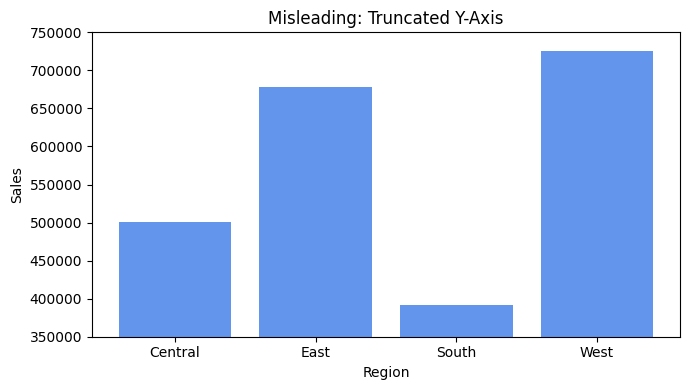

Caption: Truncated y-axis — Starting the axis at 350,000 instead of 0 makes minor differences look huge.



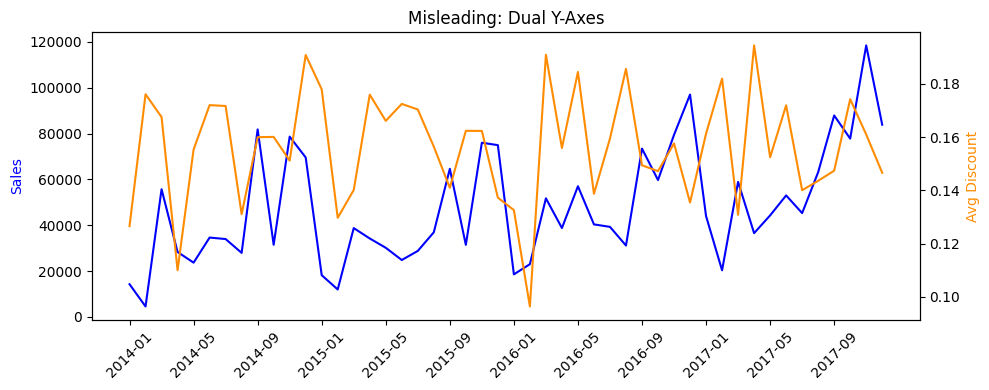

Caption: Dual y-axes — Combining two different scales creates a fake correlation between sales and discounts.



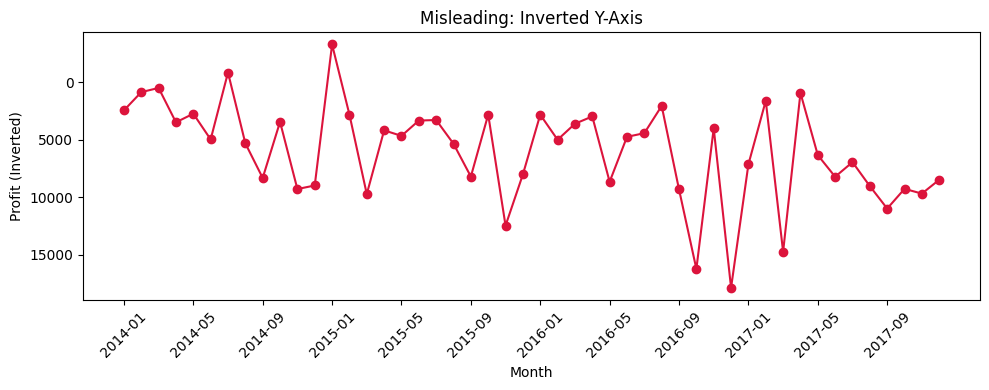

Caption: Inverted y-axis — Flipping the vertical axis makes a drop in profit look like an increase.



In [6]:
# 1. Truncated y-axis: Starting axis at 350,000 instead of 0 makes small differences look huge.
plt.figure(figsize=(7, 4))
plt.bar(region_sales['Region'], region_sales['Sales'], color='cornflowerblue')
plt.ylim(350000, 750000)
plt.title('Misleading: Truncated Y-Axis')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()
print("Caption: Truncated y-axis — Starting the axis at 350,000 instead of 0 makes minor differences look huge.\n")

# 2. Dual-axis chart: Combining two different scales creates a fake correlation between sales and discounts.
monthly_summary = df.groupby('YearMonth').agg({'Sales': 'sum', 'Discount': 'mean'}).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(monthly_summary['YearMonth'], monthly_summary['Sales'], color='blue')
ax2.plot(monthly_summary['YearMonth'], monthly_summary['Discount'], color='darkorange')
ax1.set_ylabel('Sales', color='blue')
ax2.set_ylabel('Avg Discount', color='darkorange')
ax1.set_xticks(range(0, len(monthly_summary), 4))
ax1.set_xticklabels(monthly_summary['YearMonth'][::4], rotation=45)
plt.title('Misleading: Dual Y-Axes')
plt.tight_layout()
plt.show()
print("Caption: Dual y-axes — Combining two different scales creates a fake correlation between sales and discounts.\n")

# 3. Inverted y-axis: Flipping the vertical axis makes a drop in profit look like an increase.
plt.figure(figsize=(10, 4))
plt.plot(monthly_profit['YearMonth'], monthly_profit['Profit'], marker='o', color='crimson')
plt.gca().invert_yaxis()
plt.xticks(range(0, len(monthly_profit), 4), monthly_profit['YearMonth'][::4], rotation=45)
plt.title('Misleading: Inverted Y-Axis')
plt.xlabel('Month')
plt.ylabel('Profit (Inverted)')
plt.tight_layout()
plt.show()
print("Caption: Inverted y-axis — Flipping the vertical axis makes a drop in profit look like an increase.\n")


# Task 6: Real Analytical Question

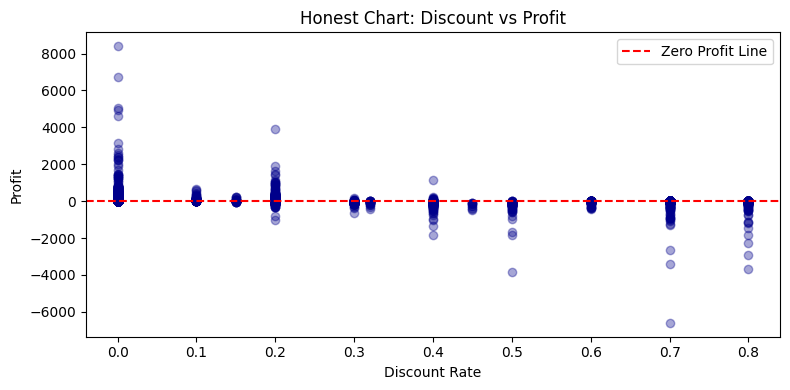

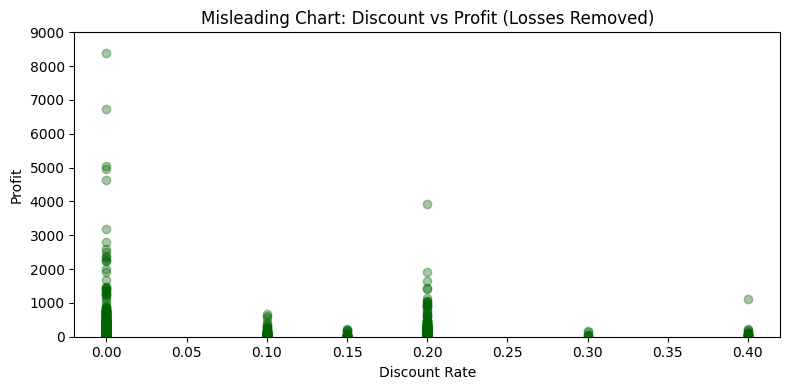

In [7]:
# Question: Does offering higher discounts hurt our profit?

# 1. Honest chart
plt.figure(figsize=(8, 4))
plt.scatter(df['Discount'], df['Profit'], alpha=0.35, color='darkblue')
plt.axhline(0, color='red', linestyle='--', label='Zero Profit Line')
plt.title('Honest Chart: Discount vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Misleading chart (Hiding negative profits)
profitable = df[df['Profit'] > 0]
plt.figure(figsize=(8, 4))
plt.scatter(profitable['Discount'], profitable['Profit'], alpha=0.35, color='darkgreen')
plt.ylim(0, 9000)
plt.title('Misleading Chart: Discount vs Profit (Losses Removed)')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

# Justification:
# - Chart Type Choice: Scatter plot shows all raw orders to reveal severe losses at high discounts; misleading chart cuts out negative profits to hide losses.
# - Color Choice: Neutral dark blue for dots and a clear red line at 0 profit avoid rainbow clutter and mark break-even clearly.
# - Accessibility Check: Contrast ratio is above 4.5:1 on white, and the zero line physically separates profit from loss without relying only on color.
